# Treinamento dos Modelos — Soja

Neste notebook serão treinados diferentes modelos de visão computacional para classificação de doenças em folhas de soja.

1. Carregamento dos dados pré-processados;
2. Definição dos experimentos no MLflow;
3. Treinamento de um modelo baseline criado do zero;
4. Treinamento de modelos pré-treinados com transfer learning;
5. Comparação entre learning rate fixo e One Cycle Policy;
6. Avaliação com matrizes de confusão;
7. Comparação final dos experimentos.

In [0]:
%load_ext autoreload
%autoreload 2

In [0]:
import torch
import mlflow
import mlflow.pytorch

import matplotlib.pyplot as plt
import seaborn as sns

from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
from sklearn.metrics import confusion_matrix

from src.dataset.soja_dataset import criar_dataloaders
from src.models.soja_models import get_model

from src.train import find_best_lr, run_training
from src.evaluate import get_predictions

In [0]:
EXPERIMENT_NAME = "/Shared/Soja_Doencas"

mlflow.set_experiment(EXPERIMENT_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Experimento:", EXPERIMENT_NAME)
print("Device:", device)

Experimento: /Shared/Soja_Doencas
Device: cpu


## 1. Carregamento dos dados

Nesta etapa carregamos os dados de soja já pré-processados e divididos em treino, validação e teste.

Os `DataLoaders` serão responsáveis por alimentar os modelos em batches durante o treinamento.

No Databricks Free Edition, utilizamos `num_workers = 0` para evitar problemas relacionados a multiprocessing.

In [0]:
train_loader, val_loader, test_loader = criar_dataloaders(
    batch_size=32,
    num_workers=0
)

classes = train_loader.dataset.classes
num_classes = len(classes)

print("Classes:", classes)
print("Número de classes:", num_classes)
print("Total treino:", len(train_loader.dataset))
print("Total validação:", len(val_loader.dataset))
print("Total teste:", len(test_loader.dataset))

Classes: ['Crestamento', 'Ferrugem', 'Mancha_Parda', 'Mosaico_Amarelo', 'Oidio', 'Podridao_Sul', 'Queima_Bacteriana', 'Septoriose', 'Sindrome_Morte_Subita', 'Soja_Saudavel', 'Virus_Mosaico']
Número de classes: 11
Total treino: 4100
Total validação: 865
Total teste: 877


## 2. Modelo criado do zero (Baseline)

Nesta seção utilizamos uma arquitetura de rede neural convolucional desenvolvida do zero (`CNN_Simples`).

O objetivo deste modelo é servir como **baseline**, ou seja:

- estabelecer um ponto de referência de desempenho;
- permitir comparação com modelos pré-treinados;
- entender a capacidade do modelo em aprender padrões diretamente dos dados, sem transfer learning.

Esse modelo será utilizado nos experimentos iniciais antes da aplicação de arquiteturas mais complexas.

### Learning Rate Finder — CNN Simples

Nesta etapa utilizamos o **Learning Rate Finder (LR Finder)** para identificar uma taxa de aprendizado adequada para o treinamento da `CNN_Simples`.

O LR Finder funciona testando múltiplos valores de learning rate ao longo de um único ciclo de treinamento e observando o comportamento da função de perda.

#### Objetivo desta etapa:

- Encontrar um intervalo de learning rates estáveis;
- Evitar valores muito baixos (treinamento lento);
- Evitar valores muito altos (divergência do modelo);
- Definir um valor inicial mais eficiente para o treinamento.

#### Configuração do experimento:

- Modelo: `cnn_simples`
- Estratégia: Treinamento do zero (sem transfer learning)
- Backbone congelado: Não aplicável, mas mantido como padrão
- Dataset: soja (dados já pré-processados e divididos)
- Registro: MLflow

O resultado será um gráfico que relaciona:

- Learning Rate vs Loss

A partir desse gráfico, será possível escolher um learning rate adequado para os próximos experimentos.

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR sugerido: 0.003944
LR suggestion: steepest gradient
Suggested LR: 3.94E-03


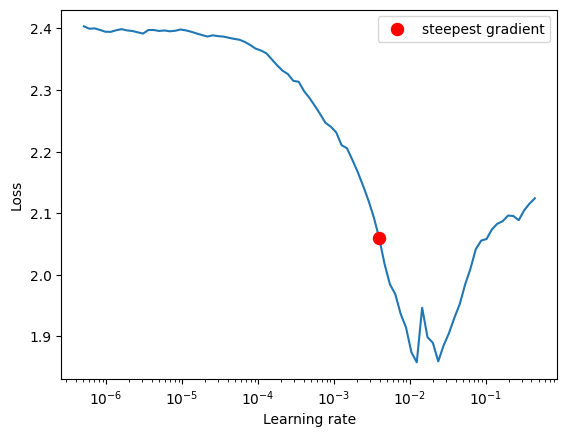

In [0]:
model_name = "simplecnn"
freeze_backbone = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="simplecnn_best_lr"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("classes", classes)

    suggested_lr, fig = find_best_lr(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        device=device,
        freeze_backbone=freeze_backbone
    )

    mlflow.log_param("suggested_lr", suggested_lr)

    fig

### Treinamento — CNN Simples com Learning Rate fixo

Nesta etapa será realizado o treinamento da `CNN_Simples` utilizando um **learning rate fixo**, previamente determinado através do LR Finder.

#### Objetivo desta etapa:

- Avaliar o desempenho do modelo utilizando uma taxa de aprendizado constante;
- Servir como baseline para comparação com estratégias mais avançadas;
- Observar a estabilidade do treinamento ao longo das épocas.

#### Configuração do experimento:

- Modelo: `cnn_simples`
- Learning Rate: valor sugerido pelo LR Finder
- Épocas: 30
- Early stopping: Sim (`patience = 5`)
- One Cycle Policy: Não
- Dataset: soja
- Registro: MLflow

Durante o treinamento serão registradas no MLflow as métricas de loss e acurácia para treino e validação.

In [0]:
model_name = "simplecnn"
learning_rate = suggested_lr
epochs = 30
freeze_backbone = True
patience = 5
use_onecycle = False

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="simplecnn"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("patience", patience)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_cnn, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        patience=patience
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_cnn(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_cnn,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.5290 | Val Acc: 0.0786
Epoch 2/30 | Train Acc: 0.6473 | Val Acc: 0.9017
Epoch 3/30 | Train Acc: 0.6778 | Val Acc: 0.9179
Epoch 4/30 | Train Acc: 0.7059 | Val Acc: 0.9665
Epoch 5/30 | Train Acc: 0.6954 | Val Acc: 0.9723
Epoch 6/30 | Train Acc: 0.7276 | Val Acc: 0.9688
Epoch 7/30 | Train Acc: 0.7456 | Val Acc: 0.4855
Epoch 8/30 | Train Acc: 0.7461 | Val Acc: 0.9780
Epoch 9/30 | Train Acc: 0.7493 | Val Acc: 0.8139
Epoch 10/30 | Train Acc: 0.7666 | Val Acc: 0.9676
Epoch 11/30 | Train Acc: 0.7807 | Val Acc: 0.9873
Epoch 12/30 | Train Acc: 0.7841 | Val Acc: 0.9792
Epoch 13/30 | Train Acc: 0.7980 | Val Acc: 0.9769
Epoch 14/30 | Train Acc: 0.8090 | Val Acc: 0.9861
Epoch 15/30 | Train Acc: 0.8183 | Val Acc: 0.9815
Epoch 16/30 | Train Acc: 0.8151 | Val Acc: 0.9723
Early stopping acionado.


2026/05/17 01:17:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-4292c8ce370c4b3eac9641d1533132c5?o=1016405703992070


#### Matriz de Confusão — CNN Simples (Learning Rate fixo)

Após o treinamento da `CNN_Simples` com learning rate fixo, realizamos a avaliação do modelo no conjunto de validação por meio da matriz de confusão.

Essa análise permite observar como o modelo está classificando cada classe individualmente, complementando métricas agregadas como acurácia e loss.

#### Objetivo desta etapa:

- Avaliar o poder de discriminação do modelo baseline;
- Identificar classes com maior dificuldade de classificação;
- Verificar possíveis confusões entre doenças visualmente semelhantes;
- Registrar a matriz de confusão como artefato no MLflow.

In [0]:
run_id_cnn = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_cnn):

    val_labels, val_preds = get_predictions(model_cnn, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_cnn_simples.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_cnn_simples.png")

### CNN Simples com One Cycle Policy

Nesta etapa será realizado o treinamento da `CNN_Simples` utilizando a estratégia de **One Cycle Policy**.

Diferente do treinamento com learning rate fixo, essa abordagem ajusta dinamicamente a taxa de aprendizado ao longo das épocas.

#### Objetivo desta etapa:

- Avaliar o desempenho da CNN com uma estratégia dinâmica de learning rate;
- Verificar se a One Cycle Policy melhora a convergência do modelo;
- Comparar os resultados com o treinamento utilizando learning rate fixo;
- Analisar se há melhora na generalização no conjunto de validação.

In [0]:
model_name = "simplecnn"
learning_rate = suggested_lr
epochs = 30
freeze_backbone = True
use_onecycle = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="simplecnn_1cycle"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_cnn_1cycle, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        use_onecycle=use_onecycle
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_cnn_1cycle(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_cnn_1cycle,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.4268 | Val Acc: 0.0832
Epoch 2/30 | Train Acc: 0.5712 | Val Acc: 0.6647
Epoch 3/30 | Train Acc: 0.6380 | Val Acc: 0.9734
Epoch 4/30 | Train Acc: 0.6946 | Val Acc: 0.9699
Epoch 5/30 | Train Acc: 0.6902 | Val Acc: 0.8497
Epoch 6/30 | Train Acc: 0.7054 | Val Acc: 0.3064
Epoch 7/30 | Train Acc: 0.7005 | Val Acc: 0.8393
Epoch 8/30 | Train Acc: 0.7241 | Val Acc: 0.9676
Epoch 9/30 | Train Acc: 0.7449 | Val Acc: 0.9931
Epoch 10/30 | Train Acc: 0.7366 | Val Acc: 0.9399
Epoch 11/30 | Train Acc: 0.7605 | Val Acc: 0.9630
Epoch 12/30 | Train Acc: 0.7720 | Val Acc: 0.9838
Epoch 13/30 | Train Acc: 0.7861 | Val Acc: 0.9850
Epoch 14/30 | Train Acc: 0.7900 | Val Acc: 0.9665
Epoch 15/30 | Train Acc: 0.8122 | Val Acc: 0.9838
Epoch 16/30 | Train Acc: 0.8173 | Val Acc: 0.9780
Epoch 17/30 | Train Acc: 0.8129 | Val Acc: 0.9850
Epoch 18/30 | Train Acc: 0.8210 | Val Acc: 0.9827
Epoch 19/30 | Train Acc: 0.8278 | Val Acc: 0.9861
Epoch 20/30 | Train Acc: 0.8456 | Val Acc: 0.9838
Epoch 21/

2026/05/17 09:23:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-435406da31014f2e9616c32a25b42eb3?o=1016405703992070


#### Matriz de Confusão — CNN Simples (One Cycle Policy)

Após o treinamento da `CNN_Simples` utilizando One Cycle Policy, avaliamos o modelo no conjunto de validação por meio da matriz de confusão.

Essa etapa permite comparar o comportamento da CNN com e sem estratégia dinâmica de learning rate.

In [0]:
run_id_cnn_1cycle = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_cnn_1cycle):

    val_labels, val_preds = get_predictions(model_cnn_1cycle, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_cnn_simples_1cycle.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_cnn_simples_1cycle.png")

## 3. Modelo pré-treinado (Transfer Learning) — ResNet18

Nesta seção utilizamos a arquitetura `ResNet18`, um modelo pré-treinado no dataset ImageNet, amplamente utilizado em tarefas de visão computacional.

O objetivo deste modelo é aplicar **transfer learning**, ou seja:

- aproveitar padrões já aprendidos em grandes volumes de dados;
- reduzir o tempo de treinamento;
- melhorar a capacidade de generalização;
- obter melhor desempenho em comparação com modelos treinados do zero.

Neste experimento, utilizamos a estratégia de:

- **Backbone congelado (`freeze_backbone = True`)**

Isso significa que:

- as camadas convolucionais permanecem fixas;
- apenas a camada final de classificação é treinada;
- o modelo adapta o conhecimento prévio ao problema específico de classificação de doenças na soja.

### Learning Rate Finder — ResNet18

Nesta etapa utilizamos o **Learning Rate Finder (LR Finder)** para identificar uma taxa de aprendizado adequada para o treinamento da `ResNet18`.

#### Objetivo desta etapa:

- Encontrar um intervalo de learning rates estáveis para fine-tuning;
- Evitar valores muito baixos;
- Evitar valores muito altos que prejudiquem os pesos pré-treinados;
- Definir um learning rate inicial adequado para o treinamento da camada final.

#### Configuração do experimento:

- Modelo: `ResNet18`
- Estratégia: Transfer learning
- Backbone congelado: Sim (`freeze_backbone = True`)
- Dataset: soja
- Registro: MLflow

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/spark-b45d089e-692c-431b-b3f3-a3/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 352MB/s]


  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR sugerido: 0.010476
LR suggestion: steepest gradient
Suggested LR: 1.05E-02


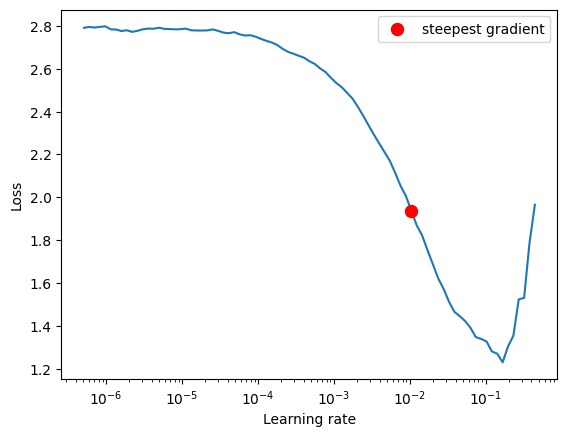

In [0]:
model_name = "resnet18"
freeze_backbone = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="resnet18_best_lr"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("classes", classes)

    suggested_lr_resnet18, fig = find_best_lr(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        device=device,
        freeze_backbone=freeze_backbone
    )

    mlflow.log_param("suggested_lr", suggested_lr_resnet18)

    fig

### Treinamento — ResNet18 com Learning Rate fixo

Nesta etapa será realizado o treinamento da `ResNet18` utilizando um learning rate fixo, definido a partir do valor sugerido pelo LR Finder.

#### Configuração do experimento:

- Modelo: `ResNet18`
- Estratégia: Transfer learning
- Backbone congelado: Sim
- Épocas: 30
- Early stopping: Sim
- One Cycle Policy: Não
- Dataset: soja
- Registro: MLflow

In [0]:
model_name = "resnet18"
learning_rate = suggested_lr_resnet18
epochs = 30
freeze_backbone = True
patience = 5
use_onecycle = False

with mlflow.start_run(run_name="resnet18"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("patience", patience)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_resnet18, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        patience=patience
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_resnet18(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_resnet18,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.8241 | Val Acc: 0.9850
Epoch 2/30 | Train Acc: 0.9407 | Val Acc: 0.9908
Epoch 3/30 | Train Acc: 0.9383 | Val Acc: 0.9896
Epoch 4/30 | Train Acc: 0.9405 | Val Acc: 0.9965
Epoch 5/30 | Train Acc: 0.9549 | Val Acc: 0.9919
Epoch 6/30 | Train Acc: 0.9527 | Val Acc: 0.9919
Epoch 7/30 | Train Acc: 0.9544 | Val Acc: 0.9861
Epoch 8/30 | Train Acc: 0.9480 | Val Acc: 0.9942
Epoch 9/30 | Train Acc: 0.9495 | Val Acc: 0.9942
Early stopping acionado.


2026/05/17 12:00:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-93500a6f6db245d28c73880712a8a9b4?o=1016405703992070


#### Matriz de Confusão — ResNet18 (Learning Rate fixo)

Após o treinamento da `ResNet18` com learning rate fixo, avaliamos o modelo no conjunto de validação utilizando a matriz de confusão.

Essa análise permite verificar se o transfer learning contribuiu para melhor discriminação entre as classes de soja.

In [0]:
run_id_resnet18 = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_resnet18):

    val_labels, val_preds = get_predictions(model_resnet18, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_resnet18.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_resnet18.png")

### ResNet18 com One Cycle Policy

Nesta etapa será realizado o treinamento da `ResNet18` utilizando a estratégia de One Cycle Policy.

O objetivo é comparar o desempenho da arquitetura com learning rate fixo e com learning rate dinâmico.

In [0]:
model_name = "resnet18"
learning_rate = suggested_lr_resnet18
epochs = 30
freeze_backbone = True
use_onecycle = True

with mlflow.start_run(run_name="resnet18_1cycle"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_resnet18_1cycle, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        use_onecycle=use_onecycle
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_resnet18_1cycle(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_resnet18_1cycle,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.6154 | Val Acc: 0.9873
Epoch 2/30 | Train Acc: 0.8949 | Val Acc: 0.9919
Epoch 3/30 | Train Acc: 0.9380 | Val Acc: 0.9942
Epoch 4/30 | Train Acc: 0.9529 | Val Acc: 0.9942
Epoch 5/30 | Train Acc: 0.9510 | Val Acc: 0.9896
Epoch 6/30 | Train Acc: 0.9439 | Val Acc: 0.9965
Epoch 7/30 | Train Acc: 0.9417 | Val Acc: 0.9954
Epoch 8/30 | Train Acc: 0.9327 | Val Acc: 0.9942
Epoch 9/30 | Train Acc: 0.9544 | Val Acc: 0.9954
Epoch 10/30 | Train Acc: 0.9566 | Val Acc: 0.9861
Epoch 11/30 | Train Acc: 0.9412 | Val Acc: 0.9954
Epoch 12/30 | Train Acc: 0.9617 | Val Acc: 0.9896
Epoch 13/30 | Train Acc: 0.9598 | Val Acc: 0.9919
Epoch 14/30 | Train Acc: 0.9693 | Val Acc: 0.9919
Epoch 15/30 | Train Acc: 0.9637 | Val Acc: 0.9977
Epoch 16/30 | Train Acc: 0.9759 | Val Acc: 0.9954


IOStream.flush timed out


Epoch 17/30 | Train Acc: 0.9720 | Val Acc: 0.9954
Epoch 18/30 | Train Acc: 0.9590 | Val Acc: 0.9942
Epoch 19/30 | Train Acc: 0.9788 | Val Acc: 0.9942
Epoch 20/30 | Train Acc: 0.9827 | Val Acc: 0.9965
Epoch 21/30 | Train Acc: 0.9783 | Val Acc: 0.9954
Epoch 22/30 | Train Acc: 0.9795 | Val Acc: 0.9965
Epoch 23/30 | Train Acc: 0.9820 | Val Acc: 0.9942
Epoch 24/30 | Train Acc: 0.9846 | Val Acc: 0.9942
Epoch 25/30 | Train Acc: 0.9876 | Val Acc: 0.9965
Epoch 26/30 | Train Acc: 0.9898 | Val Acc: 0.9942
Epoch 27/30 | Train Acc: 0.9868 | Val Acc: 0.9965
Epoch 28/30 | Train Acc: 0.9876 | Val Acc: 0.9942
Epoch 29/30 | Train Acc: 0.9849 | Val Acc: 0.9954
Epoch 30/30 | Train Acc: 0.9893 | Val Acc: 0.9965


2026/05/17 19:17:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-4e9b3be99823478097a48a7a018e6650?o=1016405703992070


#### Matriz de Confusão — ResNet18 (One Cycle Policy)

Após o treinamento da `ResNet18` com One Cycle Policy, avaliamos o modelo no conjunto de validação.

Essa matriz permitirá comparar se a estratégia dinâmica de learning rate trouxe melhoria em relação ao treinamento com learning rate fixo.

In [0]:
run_id_resnet18_1cycle = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_resnet18_1cycle):

    val_labels, val_preds = get_predictions(model_resnet18_1cycle, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_resnet18_1cycle.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_resnet18_1cycle.png")

## 4. Modelo pré-treinado (Transfer Learning) — EfficientNet-B0

Nesta seção utilizamos a arquitetura `EfficientNet-B0`, um modelo pré-treinado no dataset ImageNet e desenvolvido com foco em eficiência computacional e alto desempenho em tarefas de visão computacional.

O objetivo deste modelo é aplicar **transfer learning**, ou seja:

- aproveitar padrões previamente aprendidos em grandes datasets;
- reduzir o tempo de treinamento;
- melhorar a capacidade de generalização;
- obter melhor desempenho utilizando uma arquitetura mais eficiente.

A `EfficientNet-B0` utiliza uma estratégia de escalonamento balanceado entre:

- profundidade da rede;
- largura das camadas;
- resolução das imagens.

Isso permite alcançar bons resultados com menor custo computacional em comparação com arquiteturas mais pesadas.

Neste experimento, utilizamos a estratégia de:

- **Backbone congelado (`freeze_backbone = True`)**

Isso significa que:

- as camadas convolucionais pré-treinadas permanecem fixas;
- apenas a camada final de classificação será treinada;
- o modelo adapta o conhecimento aprendido no ImageNet ao problema específico de classificação de doenças na soja.

Este modelo será comparado com:

- CNN simples (baseline);
- ResNet18;

permitindo avaliar os ganhos obtidos com arquiteturas mais eficientes e o uso de transfer learning.

### Learning Rate Finder — EfficientNet-B0

Nesta etapa utilizamos o **Learning Rate Finder (LR Finder)** para identificar uma taxa de aprendizado adequada para o treinamento da `EfficientNet-B0`.

O LR Finder funciona testando múltiplos valores de learning rate ao longo de um único ciclo de treinamento e observando o comportamento da função de perda.

A `EfficientNet-B0` é uma arquitetura pré-treinada no ImageNet, conhecida por equilibrar bem desempenho e eficiência computacional. Por isso, ela será utilizada com **transfer learning**.

#### Objetivo desta etapa:

- Encontrar um intervalo de learning rates estáveis para fine-tuning;
- Evitar valores muito baixos (treinamento lento);
- Evitar valores muito altos (instabilidade ou degradação dos pesos pré-treinados);
- Definir um learning rate inicial adequado para o treinamento da camada final.

#### Configuração do experimento:

- Modelo: `EfficientNet-B0`
- Estratégia: Transfer learning
- Backbone congelado: Sim (`freeze_backbone = True`)
- Dataset: soja (dados já pré-processados e divididos)
- Registro: MLflow

O resultado será um gráfico que relaciona:

- Learning Rate vs Loss

A partir desse gráfico, será possível escolher um learning rate adequado para os próximos experimentos com a EfficientNet-B0.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/spark-b45d089e-692c-431b-b3f3-a3/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 247MB/s]


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR sugerido: 0.012328
LR suggestion: steepest gradient
Suggested LR: 1.23E-02


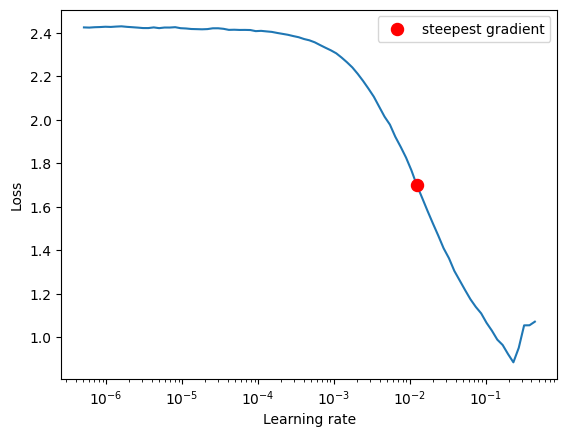

In [0]:
model_name = "efficientnet_b0"
freeze_backbone = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="efficientnet_b0_best_lr"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("classes", classes)

    suggested_lr_effnet, fig = find_best_lr(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        device=device,
        freeze_backbone=freeze_backbone
    )

    mlflow.log_param("suggested_lr", suggested_lr_effnet)

    fig

### Treinamento — EfficientNet-B0 com Learning Rate fixo

Nesta etapa será realizado o treinamento da `EfficientNet-B0` utilizando um **learning rate fixo**, definido a partir do valor sugerido pelo LR Finder.

Como a `EfficientNet-B0` é um modelo pré-treinado no ImageNet, utilizamos **transfer learning** com o backbone congelado. Dessa forma, apenas a camada final de classificação será ajustada para o problema específico de classificação de doenças na soja.

#### Objetivo desta etapa:

- Treinar a camada final da `EfficientNet-B0`;
- Avaliar o desempenho de uma arquitetura eficiente com transfer learning;
- Comparar os resultados com a CNN simples e a ResNet18;
- Verificar se a EfficientNet-B0 apresenta melhor equilíbrio entre desempenho e custo computacional.

#### Configuração do experimento:

- Modelo: `EfficientNet-B0`
- Estratégia: Transfer learning
- Backbone congelado: Sim (`freeze_backbone = True`)
- Learning Rate: valor sugerido pelo LR Finder
- Épocas: 30
- Early stopping: Sim (`patience = 5`)
- One Cycle Policy: Não
- Dataset: soja (dados já pré-processados e divididos)
- Registro: MLflow

Durante o treinamento serão registradas no MLflow as métricas de:

- Loss de treino;
- Acurácia de treino;
- Loss de validação;
- Acurácia de validação.

Ao final, o modelo treinado será salvo no MLflow junto com sua assinatura de entrada e saída, permitindo rastreabilidade e comparação com os demais experimentos.

In [0]:
model_name = "efficientnet_b0"
learning_rate = suggested_lr_effnet
epochs = 30
freeze_backbone = True
patience = 5
use_onecycle = False

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="efficientnet_b0") as run:

    run_id_effnet = run.info.run_id

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("patience", patience)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_effnetb0, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        patience=patience
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_effnetb0(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_effnetb0,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.8861 | Val Acc: 0.9884
Epoch 2/30 | Train Acc: 0.9412 | Val Acc: 0.9908
Epoch 3/30 | Train Acc: 0.9405 | Val Acc: 0.9931
Epoch 4/30 | Train Acc: 0.9515 | Val Acc: 0.9908
Epoch 5/30 | Train Acc: 0.9459 | Val Acc: 0.9977
Epoch 6/30 | Train Acc: 0.9483 | Val Acc: 0.9884
Epoch 7/30 | Train Acc: 0.9478 | Val Acc: 0.9861
Epoch 8/30 | Train Acc: 0.9595 | Val Acc: 0.9965
Epoch 9/30 | Train Acc: 0.9576 | Val Acc: 0.9942
Epoch 10/30 | Train Acc: 0.9583 | Val Acc: 0.9954
Early stopping acionado.


2026/05/17 21:50:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-8a32a0745366463dbb42fd3fd25aba14?o=1016405703992070


#### Matriz de Confusão — EfficientNet-B0 (Learning Rate fixo)

Após o treinamento da `EfficientNet-B0` com learning rate fixo, realizamos a avaliação do modelo no conjunto de validação utilizando a matriz de confusão.

Essa análise permite observar de forma mais detalhada como o modelo está classificando cada classe individualmente, complementando métricas agregadas como acurácia e loss.

#### Objetivo desta etapa:

- Avaliar o poder de discriminação da `EfficientNet-B0`;
- Identificar classes com maior dificuldade de classificação;
- Verificar possíveis melhorias em relação à CNN simples e à ResNet18;
- Registrar a matriz de confusão como artefato no MLflow.

In [0]:
with mlflow.start_run(run_id=run_id_effnet):

    val_labels, val_preds = get_predictions(model_effnetb0, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_effnet_b0.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_effnet_b0.png")

### EfficientNet-B0 com One Cycle Policy

Nesta etapa será realizado o treinamento da `EfficientNet-B0` utilizando a estratégia de **One Cycle Policy**.

Diferente do treinamento com learning rate fixo, essa abordagem ajusta dinamicamente a taxa de aprendizado ao longo das épocas, buscando melhorar a convergência e a capacidade de generalização do modelo.

#### Objetivo desta etapa:

- Avaliar o desempenho da `EfficientNet-B0` com uma estratégia dinâmica de learning rate;
- Verificar se a One Cycle Policy melhora a estabilidade do treinamento;
- Comparar os resultados com a EfficientNet-B0 treinada com learning rate fixo;
- Analisar se a combinação entre transfer learning e One Cycle Policy melhora a performance no conjunto de validação.

In [0]:
model_name = "efficientnet_b0"
learning_rate = suggested_lr_effnet
epochs = 30
freeze_backbone = True
use_onecycle = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="efficientnet_b0_1cycle") as run:

    run_id_effnet_1cycle = run.info.run_id

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_effnetb0_1cycle, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        use_onecycle=use_onecycle
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_effnetb0_1cycle(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_effnetb0_1cycle,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.7646 | Val Acc: 0.9954
Epoch 2/30 | Train Acc: 0.9207 | Val Acc: 0.9965
Epoch 3/30 | Train Acc: 0.9461 | Val Acc: 0.9954
Epoch 4/30 | Train Acc: 0.9571 | Val Acc: 0.9931
Epoch 5/30 | Train Acc: 0.9588 | Val Acc: 0.9954
Epoch 6/30 | Train Acc: 0.9517 | Val Acc: 0.9942
Epoch 7/30 | Train Acc: 0.9546 | Val Acc: 0.9942
Epoch 8/30 | Train Acc: 0.9520 | Val Acc: 0.9931
Epoch 9/30 | Train Acc: 0.9512 | Val Acc: 0.9942
Epoch 10/30 | Train Acc: 0.9471 | Val Acc: 0.9919
Epoch 11/30 | Train Acc: 0.9578 | Val Acc: 0.9942
Epoch 12/30 | Train Acc: 0.9546 | Val Acc: 0.9942
Epoch 13/30 | Train Acc: 0.9595 | Val Acc: 0.9919
Epoch 14/30 | Train Acc: 0.9600 | Val Acc: 0.9954
Epoch 15/30 | Train Acc: 0.9605 | Val Acc: 0.9977
Epoch 16/30 | Train Acc: 0.9585 | Val Acc: 0.9965
Epoch 17/30 | Train Acc: 0.9607 | Val Acc: 0.9919
Epoch 18/30 | Train Acc: 0.9620 | Val Acc: 0.9931
Epoch 19/30 | Train Acc: 0.9663 | Val Acc: 0.9965
Epoch 20/30 | Train Acc: 0.9654 | Val Acc: 0.9931
Epoch 21/

2026/05/18 04:48:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-8194c6abc7854315a99e19b4adf61fc9?o=1016405703992070


#### Matriz de Confusão — EfficientNet-B0 (One Cycle Policy)

Após o treinamento da `EfficientNet-B0` utilizando a estratégia de One Cycle Policy, realizamos a avaliação do modelo no conjunto de validação por meio da matriz de confusão.

Essa análise permite comparar o comportamento da arquitetura com learning rate fixo e com uma estratégia dinâmica de ajuste da taxa de aprendizado.

#### Objetivo desta etapa:

- Avaliar o poder de discriminação da `EfficientNet-B0` utilizando One Cycle Policy;
- Comparar os resultados com a versão treinada com learning rate fixo;
- Verificar possíveis melhorias na generalização do modelo;
- Registrar a matriz de confusão como artefato no MLflow.

In [0]:
with mlflow.start_run(run_id=run_id_effnet_1cycle):

    val_labels, val_preds = get_predictions(model_effnetb0_1cycle, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_effnet_b0_1cycle.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_effnet_b0_1cycle.png")

## 5. Modelo pré-treinado (Transfer Learning) — DenseNet121

Nesta seção utilizamos a arquitetura `DenseNet121`, um modelo pré-treinado no dataset ImageNet e amplamente utilizado em tarefas de visão computacional devido à sua capacidade de reutilização de características ao longo da rede.

O objetivo deste modelo é aplicar **transfer learning**, ou seja:

- aproveitar padrões previamente aprendidos em grandes datasets;
- reduzir o tempo de treinamento;
- melhorar a capacidade de generalização;
- explorar uma arquitetura mais profunda e densamente conectada.

A `DenseNet121` utiliza conexões densas entre as camadas da rede, permitindo que:

- características aprendidas sejam reutilizadas ao longo do modelo;
- o fluxo de gradientes seja mais eficiente;
- a perda de informação entre camadas seja reduzida.

Neste experimento, utilizamos a estratégia de:

- **Backbone congelado (`freeze_backbone = True`)**

Isso significa que:

- as camadas convolucionais pré-treinadas permanecem fixas;
- apenas a camada final de classificação será treinada;
- o modelo adapta o conhecimento aprendido no ImageNet ao problema específico de classificação de doenças na soja.

Este modelo será comparado com:

- CNN simples (baseline);
- ResNet18;
- EfficientNet-B0;

permitindo avaliar os ganhos obtidos com arquiteturas mais profundas e o uso de transfer learning.

### Learning Rate Finder — DenseNet121

Nesta etapa utilizamos o **Learning Rate Finder (LR Finder)** para identificar uma taxa de aprendizado adequada para o treinamento da `DenseNet121`.

O LR Finder funciona testando múltiplos valores de learning rate ao longo de um único ciclo de treinamento e observando o comportamento da função de perda.

A `DenseNet121` é uma arquitetura pré-treinada no ImageNet, conhecida por suas conexões densas entre camadas, que favorecem a reutilização de características e melhor fluxo de gradientes.

#### Objetivo desta etapa:

- Encontrar um intervalo de learning rates estáveis para fine-tuning;
- Evitar valores muito baixos (treinamento lento);
- Evitar valores muito altos (instabilidade ou degradação dos pesos pré-treinados);
- Definir um learning rate inicial adequado para o treinamento da camada final.

#### Configuração do experimento:

- Modelo: `DenseNet121`
- Estratégia: Transfer learning
- Backbone congelado: Sim (`freeze_backbone = True`)
- Dataset: soja (dados já pré-processados e divididos)
- Registro: MLflow

O resultado será um gráfico que relaciona:

- Learning Rate vs Loss

A partir desse gráfico, será possível escolher um learning rate adequado para os próximos experimentos com a DenseNet121.

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/spark-b45d089e-692c-431b-b3f3-a3/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 316MB/s]


  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR sugerido: 0.010476
LR suggestion: steepest gradient
Suggested LR: 1.05E-02


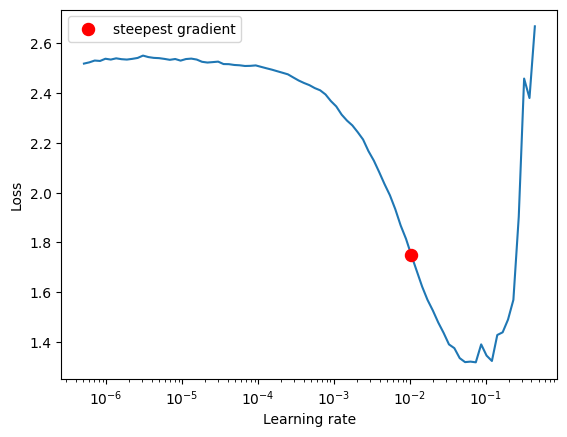

In [0]:
model_name = "densenet121"
freeze_backbone = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="densenet121_best_lr"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("classes", classes)

    suggested_lr_densenet, fig = find_best_lr(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        device=device,
        freeze_backbone=freeze_backbone
    )

    mlflow.log_param("suggested_lr", suggested_lr_densenet)

    fig

### Treinamento — DenseNet121 com Learning Rate fixo

Nesta etapa será realizado o treinamento da `DenseNet121` utilizando um **learning rate fixo**, definido a partir do valor sugerido pelo LR Finder.

Como a `DenseNet121` é um modelo pré-treinado no ImageNet, utilizamos **transfer learning** com o backbone congelado. Dessa forma, apenas a camada final de classificação será ajustada para o problema específico de classificação de doenças na soja.

#### Objetivo desta etapa:

- Treinar a camada final da `DenseNet121`;
- Avaliar o desempenho de uma arquitetura mais profunda com transfer learning;
- Comparar os resultados com a CNN simples, ResNet18 e EfficientNet-B0;
- Verificar se as conexões densas da arquitetura contribuem para melhor generalização.

#### Configuração do experimento:

- Modelo: `DenseNet121`
- Estratégia: Transfer learning
- Backbone congelado: Sim (`freeze_backbone = True`)
- Learning Rate: valor sugerido pelo LR Finder
- Épocas: 30
- Early stopping: Sim (`patience = 5`)
- One Cycle Policy: Não
- Dataset: soja (dados já pré-processados e divididos)
- Registro: MLflow

Durante o treinamento serão registradas no MLflow as métricas de:

- Loss de treino;
- Acurácia de treino;
- Loss de validação;
- Acurácia de validação.

Ao final, o modelo treinado será salvo no MLflow junto com sua assinatura de entrada e saída, permitindo rastreabilidade e comparação com os demais experimentos.

In [0]:
model_name = "densenet121"
learning_rate = suggested_lr_densenet
epochs = 30
freeze_backbone = True
patience = 5
use_onecycle = False

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="densenet121") as run:

    run_id_densenet = run.info.run_id

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("patience", patience)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_densenet, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        patience=patience
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_densenet(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_densenet,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.8544 | Val Acc: 0.9896
Epoch 2/30 | Train Acc: 0.9585 | Val Acc: 0.9954
Epoch 3/30 | Train Acc: 0.9515 | Val Acc: 0.9965
Epoch 4/30 | Train Acc: 0.9727 | Val Acc: 0.9965
Epoch 5/30 | Train Acc: 0.9610 | Val Acc: 0.9931
Epoch 6/30 | Train Acc: 0.9705 | Val Acc: 0.9896
Epoch 7/30 | Train Acc: 0.9576 | Val Acc: 0.9942
Early stopping acionado.


2026/05/18 07:23:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-6e1f2ef3ac704188b0ea5a9d675ca77d?o=1016405703992070


#### Matriz de Confusão — DenseNet121 (Learning Rate fixo)

Após o treinamento da `DenseNet121` com learning rate fixo, realizamos a avaliação do modelo no conjunto de validação utilizando a matriz de confusão.

Essa análise permite observar com maior profundidade como o modelo está classificando cada classe individualmente, complementando métricas agregadas como acurácia e loss.

#### Objetivo desta etapa:

- Avaliar o poder de discriminação da `DenseNet121`;
- Identificar classes com maior dificuldade de classificação;
- Verificar possíveis melhorias em relação aos demais modelos;
- Registrar a matriz de confusão como artefato no MLflow.

In [0]:
with mlflow.start_run(run_id=run_id_densenet):

    val_labels, val_preds = get_predictions(model_densenet, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_densenet121.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_densenet121.png")

### DenseNet121 com One Cycle Policy

Nesta etapa será realizado o treinamento da `DenseNet121` utilizando a estratégia de **One Cycle Policy**.

Diferente do treinamento com learning rate fixo, essa abordagem ajusta dinamicamente a taxa de aprendizado ao longo das épocas, buscando melhorar a convergência e a capacidade de generalização do modelo.

#### Objetivo desta etapa:

- Avaliar o desempenho da `DenseNet121` com uma estratégia dinâmica de learning rate;
- Verificar se a One Cycle Policy melhora a estabilidade do treinamento;
- Comparar os resultados com a DenseNet121 treinada com learning rate fixo;
- Analisar se a combinação entre transfer learning, conexões densas e One Cycle Policy melhora a performance no conjunto de validação.

In [0]:
model_name = "densenet121"
learning_rate = suggested_lr_densenet
epochs = 30
freeze_backbone = True
use_onecycle = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="densenet121_1cycle") as run:

    run_id_densenet_1cycle = run.info.run_id

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_densenet_1cycle, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        use_onecycle=use_onecycle
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_densenet_1cycle(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_densenet_1cycle,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.7193 | Val Acc: 0.9838
Epoch 2/30 | Train Acc: 0.9102 | Val Acc: 0.9873
Epoch 3/30 | Train Acc: 0.9446 | Val Acc: 0.9954
Epoch 4/30 | Train Acc: 0.9654 | Val Acc: 0.9931
Epoch 5/30 | Train Acc: 0.9759 | Val Acc: 0.9919
Epoch 6/30 | Train Acc: 0.9693 | Val Acc: 0.9884
Epoch 7/30 | Train Acc: 0.9602 | Val Acc: 0.9931
Epoch 8/30 | Train Acc: 0.9561 | Val Acc: 0.9792
Epoch 9/30 | Train Acc: 0.9522 | Val Acc: 0.9908
Epoch 10/30 | Train Acc: 0.9768 | Val Acc: 0.9884
Epoch 11/30 | Train Acc: 0.9739 | Val Acc: 0.9942
Epoch 12/30 | Train Acc: 0.9812 | Val Acc: 0.9931
Epoch 13/30 | Train Acc: 0.9715 | Val Acc: 0.9919
Epoch 14/30 | Train Acc: 0.9712 | Val Acc: 0.9954
Epoch 15/30 | Train Acc: 0.9827 | Val Acc: 0.9908
Epoch 16/30 | Train Acc: 0.9744 | Val Acc: 0.9942
Epoch 17/30 | Train Acc: 0.9817 | Val Acc: 0.9942
Epoch 18/30 | Train Acc: 0.9846 | Val Acc: 0.9954
Epoch 19/30 | Train Acc: 0.9868 | Val Acc: 0.9954
Epoch 20/30 | Train Acc: 0.9717 | Val Acc: 0.9954
Epoch 21/

2026/05/18 17:30:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-13657f83524e484ab5b070c974f9ca7e?o=1016405703992070


#### Matriz de Confusão — DenseNet121 (One Cycle Policy)

Após o treinamento da `DenseNet121` utilizando a estratégia de One Cycle Policy, realizamos a avaliação do modelo no conjunto de validação por meio da matriz de confusão.

Essa análise permite comparar o comportamento da arquitetura com learning rate fixo e com uma estratégia dinâmica de ajuste da taxa de aprendizado.

#### Objetivo desta etapa:

- Avaliar o poder de discriminação da `DenseNet121` utilizando One Cycle Policy;
- Comparar os resultados com a versão treinada com learning rate fixo;
- Verificar possíveis melhorias na generalização do modelo;
- Registrar a matriz de confusão como artefato no MLflow.

In [0]:
with mlflow.start_run(run_id=run_id_densenet_1cycle):

    val_labels, val_preds = get_predictions(model_densenet_1cycle, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_densenet121_1cycle.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_densenet121_1cycle.png")

## 6. Análise comparativa dos experimentos

Após a execução dos diferentes treinamentos, realizamos uma análise consolidada dos resultados obtidos ao longo dos experimentos.

Nesta etapa serão comparados os modelos treinados utilizando:

- arquiteturas distintas;
- estratégias de learning rate;
- diferentes abordagens de treinamento.

A análise será baseada principalmente nas métricas obtidas no conjunto de validação, permitindo identificar quais modelos apresentaram melhor capacidade de generalização.

#### Objetivos desta etapa

- Comparar o desempenho entre os modelos treinados;
- Avaliar o impacto do transfer learning;
- Verificar os efeitos da One Cycle Policy;
- Identificar possíveis sinais de overfitting;
- Selecionar os experimentos com melhor equilíbrio entre acurácia e loss.

In [0]:
experiment_name = "/Shared/Soja_Doencas"

experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

df_compare = runs[[
    "run_id",
    "params.model_name",
    "params.learning_rate",
    "params.use_onecycle",
    "params.epochs",
    "metrics.train_acc",
    "metrics.val_acc",
    "metrics.train_loss",
    "metrics.val_loss"
]].copy()

df_compare.columns = [
    "run_id",
    "model",
    "lr",
    "onecycle",
    "epochs",
    "train_acc",
    "val_acc",
    "train_loss",
    "val_loss"
]

df_compare["score"] = (
    df_compare["val_acc"] - 0.1 * df_compare["val_loss"]
)

df_compare = df_compare.sort_values(
    by="score",
    ascending=False
)

spark_df_compare = spark.createDataFrame(df_compare)
spark_df_compare.write.format("delta").mode("overwrite").saveAsTable("`agro-diasease`.df_compare")

df_compare.head(8)

,run_id,model,lr,onecycle,epochs,train_acc,val_acc,train_loss,val_loss,score
6,b2d796ffff814bf0b276248b94f37a5e,resnet18,0.010476157527896641,True,30,0.989268,0.996532,0.030713,0.010589,0.995473
0,e0b5090fd3cf4cc2a6cf9986aa98dc77,densenet121,0.010476157527896641,True,30,0.994634,0.995376,0.016340,0.017222,0.993654
4,12c278518dd74617b103b6637e512a39,efficientnet_b0,0.012328467394420665,False,30,0.958293,0.995376,0.173475,0.018419,0.993534
3,f7a7acabcccf4896846a37d114d5b63d,efficientnet_b0,0.012328467394420665,True,30,0.977317,0.994220,0.088374,0.014517,0.992768
7,cfc3b2b759d84bf2ac5d8bc55bd22c61,resnet18,0.010476157527896641,False,30,0.949512,0.994220,0.188049,0.026433,0.991576
1,c5d9c69c0e6d41779db1e988a111cda0,densenet121,0.010476157527896641,False,30,0.957561,0.994220,0.167227,0.035611,0.990659
9,5778c686dfca4da984b3efd37d854e7d,simplecnn,0.003944206059437656,True,30,0.888049,0.988439,0.251004,0.034269,0.985012
10,b7688584695b4638963cd6f7dd793457,simplecnn,0.003944206059437656,False,30,0.815122,0.972254,0.414936,0.097766,0.962478


## 7. Seleção do Modelo

A escolha do modelo final foi realizada com base em uma análise quantitativa e qualitativa dos experimentos registrados no MLflow.

#### Estratégia de seleção:

Os modelos foram ranqueados utilizando um score combinado:

score = val_acc - 0.1 * val_loss

Essa abordagem permite:

- Priorizar modelos com alta acurácia
- Penalizar modelos com baixa confiança (loss elevada)

#### Critério final:

1. Maior score combinado  
2. Menor loss de validação (em caso de empate)  
3. Análise da matriz de confusão  

In [0]:
best_run = df_compare.iloc[0]

print("🏆 Melhor modelo encontrado:")
print(best_run)

🏆 Melhor modelo encontrado:
run_id        b2d796ffff814bf0b276248b94f37a5e
model                                 resnet18
lr                        0.010476157527896641
onecycle                                  True
epochs                                      30
train_acc                             0.989268
val_acc                               0.996532
train_loss                            0.030713
val_loss                              0.010589
score                                 0.995473
Name: 6, dtype: object
